In [1]:
#10 data points are given 
import numpy as np
!pip install matplotlib
import pandas as pd
import os
import matplotlib.pyplot as plt
!pip install scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score




In [2]:
def convert_to_numeric(label):
    return 1 if label == "pass" else 0


In [3]:
# Step 2: Create the data array with converted numeric labels
data = np.array([
    [15.5, 40, convert_to_numeric("fail")],
    [23.75, 23.25, convert_to_numeric("fail")],
    [8, 17, convert_to_numeric("pass")],
    [17, 21, convert_to_numeric("fail")],
    [5.5, 10, convert_to_numeric("pass")],
    [19, 12, convert_to_numeric("pass")],
    [24, 20, convert_to_numeric("fail")],
    [2.5, 12, convert_to_numeric("pass")],
    [7.5, 15, convert_to_numeric("pass")],
    [11, 26, convert_to_numeric("fail")],
])

# Step 3: Create a DataFrame
df = pd.DataFrame(data, columns=["Propellant age (Weeks)", "Storage temperature (°C)", "Pass/fail for application"])
print(df)

# Step 4: Extract features and labels
features = df[["Propellant age (Weeks)", "Storage temperature (°C)"]].to_numpy()
labels = df["Pass/fail for application"].to_numpy()

# Check the extracted features and labels
print("Features:\n", features)
print("Labels:\n", labels)


   Propellant age (Weeks)  Storage temperature (°C)  Pass/fail for application
0                   15.50                     40.00                        0.0
1                   23.75                     23.25                        0.0
2                    8.00                     17.00                        1.0
3                   17.00                     21.00                        0.0
4                    5.50                     10.00                        1.0
5                   19.00                     12.00                        1.0
6                   24.00                     20.00                        0.0
7                    2.50                     12.00                        1.0
8                    7.50                     15.00                        1.0
9                   11.00                     26.00                        0.0
Features:
 [[15.5  40.  ]
 [23.75 23.25]
 [ 8.   17.  ]
 [17.   21.  ]
 [ 5.5  10.  ]
 [19.   12.  ]
 [24.   20.  ]
 [ 2.5  12.  ]


## kNN classification model


In [4]:
# Create kNN classifier with k = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the data
knn.fit(features,labels)

KNeighborsClassifier()

## plot decision boundary

In [5]:
# function for plotting
def plot_decision_boundary(model, X, y, n_neighbors):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    h = .02  # Step size in the mesh

    # Generating mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predicting the class labels for each point in the meshgrid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshaping the result to create a grid of predictions
    Z = Z.reshape(xx.shape)

    # Plotting the decision boundary and the data points
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plotting training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"kNN Decision Boundary (k={n_neighbors})")
    plt.xlabel('Propellant age (Weeks)')
    plt.ylabel('Storage temperature (°C)')
    plt.savefig("kNN Decision Boundary.png")

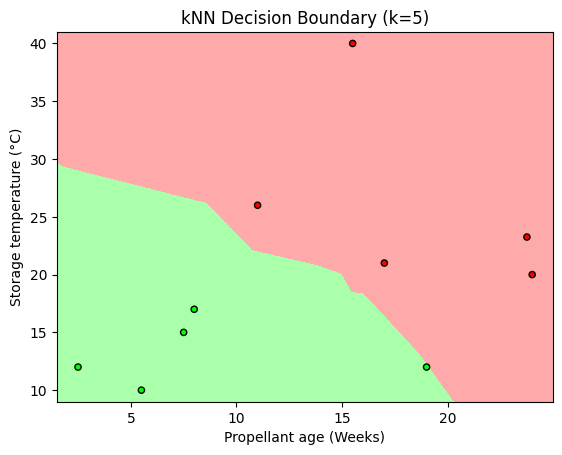

<Figure size 640x480 with 0 Axes>

In [6]:
plot_decision_boundary(knn,features,labels, n_neighbors=5)
plt.show()
plt.savefig("kNN Decision Boundary.png")

plot_decision_boundary(knn, features,labels, n_neighbors=5)
plt.show()
plt.savefig("kNN Decision Boundary.png")

### Leave-One-Out Cross-Validation (LOOCV)

In [7]:
# LOOCV Cross Validation

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

def predictor_for_LOOCV(test_index, value1, value2, k):
    query_point = np.array([value1, value2])
    distances = [euclidean_distance(query_point, x) for i, x in enumerate(data[:, :2]) if i != test_index]
    sorted_indices = np.argsort(distances)
    sorted_coordinates = data[sorted_indices]
    
    top_k_coordinates = sorted_coordinates[:k]
    average_status = np.mean(top_k_coordinates[:, 2])
    
    return average_status

def loocv(k):
    loocv_results = []
    
    for test_index in range(len(data)):
        value1 = data[test_index, 0]
        value2 = data[test_index, 1]
        average_status = predictor_for_LOOCV(test_index, value1, value2,k)
        loocv_results.append(average_status)
    
    return loocv_results

In [8]:

def compare_results(predictions, actual_values, k):
    comparison = [1 if pred == actual else 0 for pred, actual in zip(predictions, actual_values)]
    accuracy = sum(comparison) / len(comparison)
    
    plt.plot(actual_values, label='Actual Values', marker='o')
    plt.plot(comparison, label='Predicted Values', marker='x')
    
    plt.xlabel("Data Point Index")
    plt.ylabel("Match (1) / Mismatch (0)")
    plt.title(f"LOOCV Prediction Comparison (k = {k})")
    plt.legend()
    
    # Create a folder if it doesn't exist
    if not os.path.exists("graphs"):
        os.makedirs("graphs")
    
    filename = f"graphs/comparison_k_{k}.png"
    plt.savefig(filename)  # Save the figure
    
    plt.show()
    
    return accuracy

LOOCV Results for k = 1:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 1
Index 8: 1
Index 9: 0


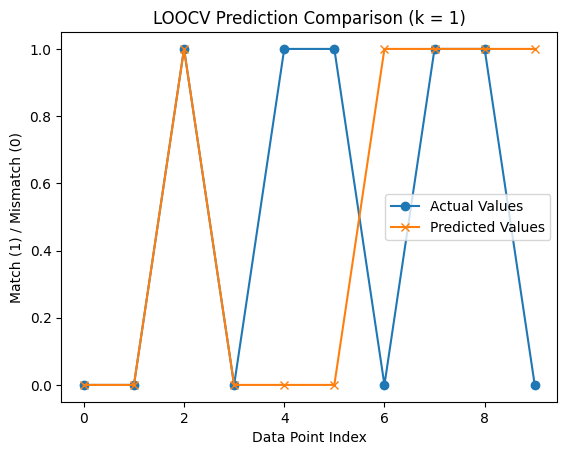

Accuracy for k = 1: 0.5
------------------------------
LOOCV Results for k = 2:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 0
Index 7: 1
Index 8: 1
Index 9: 1


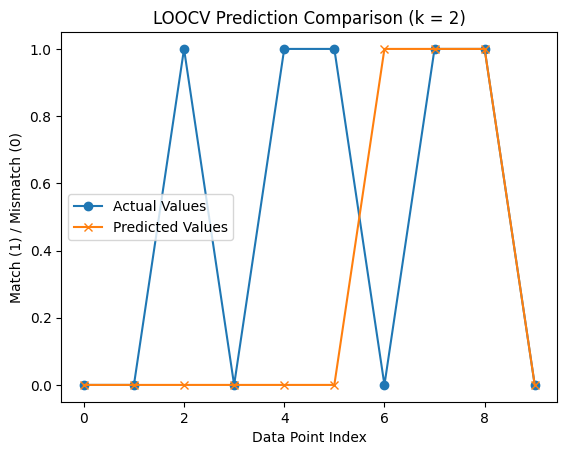

Accuracy for k = 2: 0.3
------------------------------
LOOCV Results for k = 3:
Index 0: 1
Index 1: 1
Index 2: 0
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 0
Index 7: 1
Index 8: 1
Index 9: 1


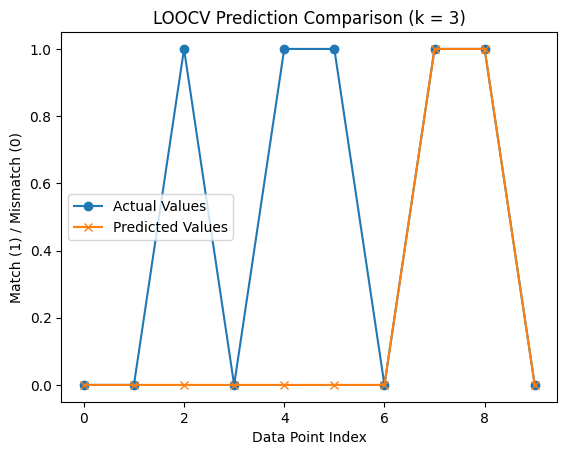

Accuracy for k = 3: 0.2
------------------------------
LOOCV Results for k = 4:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 1


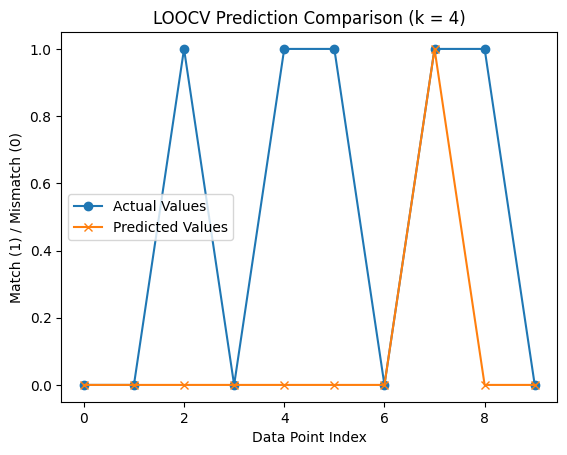

Accuracy for k = 4: 0.1
------------------------------
LOOCV Results for k = 5:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 0


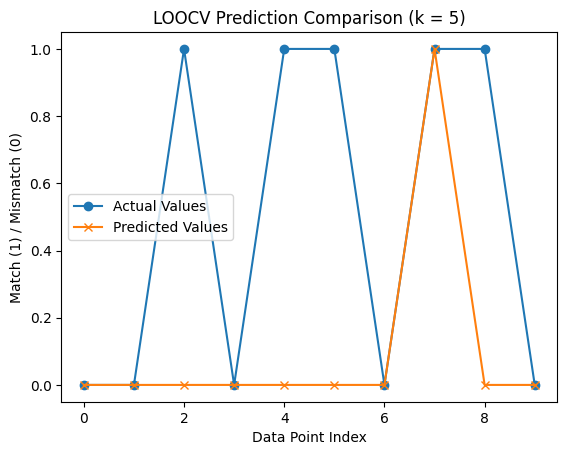

Accuracy for k = 5: 0.1
------------------------------
LOOCV Results for k = 6:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 0


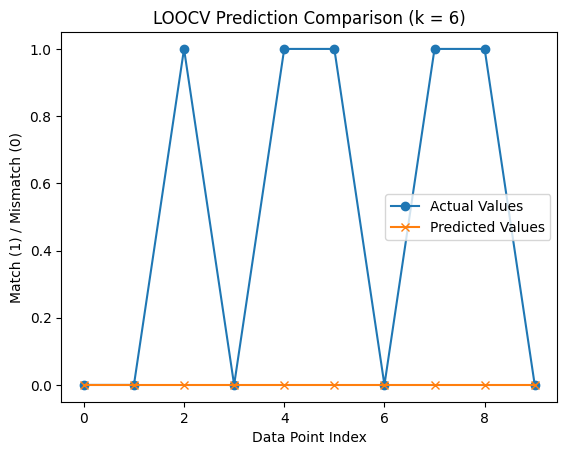

Accuracy for k = 6: 0.0
------------------------------
LOOCV Results for k = 7:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 0


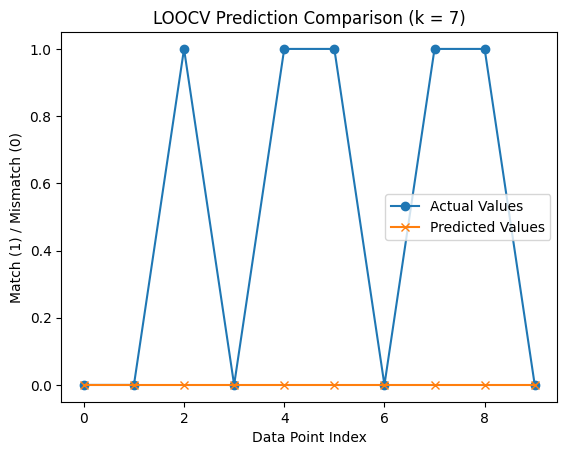

Accuracy for k = 7: 0.0
------------------------------
LOOCV Results for k = 8:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 1


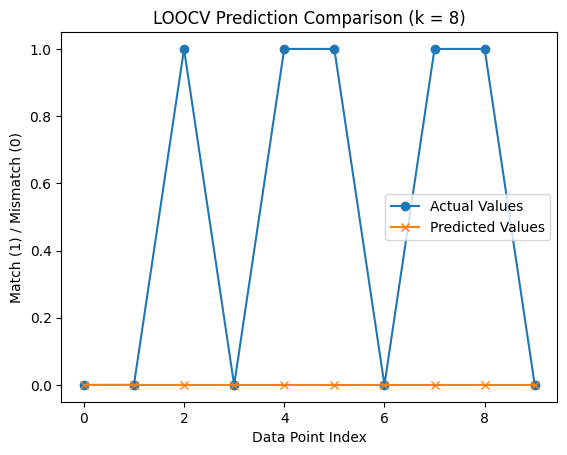

Accuracy for k = 8: 0.0
------------------------------
LOOCV Results for k = 9:
Index 0: 1
Index 1: 1
Index 2: 1
Index 3: 1
Index 4: 1
Index 5: 1
Index 6: 1
Index 7: 1
Index 8: 1
Index 9: 1


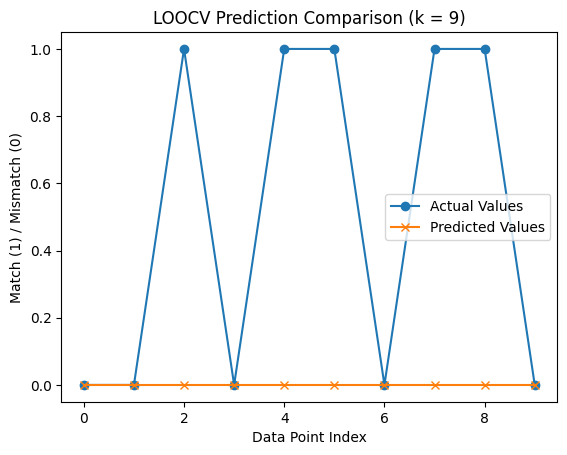

Accuracy for k = 9: 0.0
------------------------------
Maximum accuracy achieved: 0.5 with k = 1


In [9]:
def main():
    
    actual_values = data[:, 2]
    max_accuracy = 0.0
    best_k = 0
    ans = 0
    
    for k in range(1, 10):
        loocv_results = loocv(k)
        print(f"LOOCV Results for k = {k}:")
        for index, average_status in enumerate(loocv_results):
            class_label = 1 if average_status >= 0.5 else 0
            print(f"Index {index}: {class_label}")
        
        accuracy = compare_results(loocv_results, actual_values, k)
        print(f"Accuracy for k = {k}: {accuracy}")
        print('-' * 30)
        
        if accuracy > max_accuracy:
            max_accuracy = accuracy
            best_k = k
    
    print(f"Maximum accuracy achieved: {max_accuracy} with k = {best_k}")
    

if __name__ == "__main__":
    main()